In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp



In [15]:
which_dataset = 'GUT.ERP015450'
which_dataset = 'Soil'
dataset_name = 'Grilli.{}'.format(which_dataset)

In [19]:
with open('../../out/{}.absolute_abundances/eigvects.{}.absolute_abundances.dat'.format(dataset_name,dataset_name),'rb') as f:
    absolute_abu_eigvects = pickle.load(f)
    f.close()

with open('../../out/{}.absolute_abundances/family_tags.filtered.{}.absolute_abundances.dat'.format(dataset_name,dataset_name),'rb') as f:
    absolute_family_tags = pickle.load(f)
    f.close()

with open('../../out/{}.absolute_abundances/eigvals.{}.absolute_abundances.dat'.format(dataset_name,dataset_name),'rb') as f:
    absolute_eigvals = pickle.load(f)
    f.close()

with open('../../out/{}.absolute_abundances/mean_sorted_taxa.{}.absolute_abundances.dat'.format(dataset_name,dataset_name),'rb') as f:
    abs_taxa_indices = pickle.load(f) #mean sorted abundances in absolute abundance dataset
    abs_taxa_indices = np.array(abs_taxa_indices)
    f.close()

with open('../../out/{}/mean_sorted_taxa.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    taxa_indices = pickle.load(f) #mean sorted abundances in relative abundance dataset
    taxa_indices = np.array(taxa_indices)
    print(np.shape(taxa_indices))
    f.close()

with open('../../out/{}/eigvects.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    relative_abu_eigvects = pickle.load(f)
    f.close()

with open('../../datasets/true_datasets/full_dataset.{}.dat'.format(dataset_name),'rb') as f:
    full_dataset = pickle.load(f)
    M,_ = np.shape(full_dataset) #M is the number of samples
    print('M',M)
    f.close()



recast_absolute_abu_eigvects = np.zeros(np.shape(absolute_abu_eigvects))
recast_family_tags = []
recast_abs_taxa_indices = np.zeros(len(abs_taxa_indices))
for i in range(len(taxa_indices)):
    ''' Undo ordering to go back to original taxa order. '''
    index = np.where(abs_taxa_indices==i)[0][0]
    recast_absolute_abu_eigvects[i,:] = absolute_abu_eigvects[index,:]
    recast_abs_taxa_indices[i] = abs_taxa_indices[index] 
    recast_family_tags.append(absolute_family_tags[index])

## Reorder again using the order in the relative abundance dataset
absolute_abu_eigvects = recast_absolute_abu_eigvects[taxa_indices,:]


(561,)
M 112


In [20]:
''' Keep only the eigenvectors corresponding to low-variance modes.
The number of modes to be kept is in table 'tab:eigenspace_overlaps' of the manuscript '''
how_many_lowvar_modes = {}
how_many_lowvar_modes['activatedsludge'] = (342,243)
how_many_lowvar_modes['Glacier'] = (19,15)
how_many_lowvar_modes['GUT'] = (181,157)
how_many_lowvar_modes['Lake'] = (66,60)
how_many_lowvar_modes['Oral'] = (60,45)
how_many_lowvar_modes['River'] = (95,94)
how_many_lowvar_modes['Soil'] = (44,35)
how_many_lowvar_modes['GUT.SRP056641'] = (31,31)
how_many_lowvar_modes['GUT.ERP015450'] = (113,107)


In [21]:
absolute_abu_eigvects = absolute_abu_eigvects[:,-(M-1):-(M-1)+how_many_lowvar_modes[which_dataset][0]]
relative_abu_eigvects = relative_abu_eigvects[:,-(M-1):-(M-1)+how_many_lowvar_modes[which_dataset][1]]


In [22]:
relative_abu_eigvects.shape

(561, 35)

In [23]:
subspace_angles = sp.linalg.subspace_angles(absolute_abu_eigvects,relative_abu_eigvects)
k = np.shape(subspace_angles)
s = np.cos(subspace_angles)
overlap = np.mean(s)
print(overlap)
print(subspace_angles*360/2/np.pi)

0.8568308039561832
[69.31568962 61.97620709 56.88811951 54.04325059 49.8188293  44.60567624
 42.88521587 42.41376295 38.64559055 33.50142218 31.51260952 30.95847966
 28.41694758 26.04302812 25.08254356 22.43360008 21.39357869 20.6397664
 20.44518606 19.75978048 18.02176589 17.85558084 16.75933402 16.49484621
 15.71514769 15.22562869 14.65647751 13.8488797  13.61174775 13.05120194
 12.79474041 12.10479538 11.75417928 11.22799765 10.75120225]


In [24]:
random_overlaps = []
random_angles = []
rand_diagonal_angles = []
rand_diagonal_correlations =[]
for i in range(1000):
    if i%100==0: print(i)
    ''' Shuffle eigenvectors of one of the two subspaces '''
    shuffled_eigvects = np.copy(relative_abu_eigvects)
    _1,_2 = np.shape(shuffled_eigvects)
    shuffled_species = np.arange(_1)
    for vec in range(_2):
        np.random.shuffle(shuffled_species)
        shuffled_eigvects[:,vec] = shuffled_eigvects[shuffled_species,vec]

    
    random_subspace_angles = sp.linalg.subspace_angles(absolute_abu_eigvects,shuffled_eigvects)

    random_overlap = np.mean(np.cos(random_subspace_angles))
    random_overlaps.append(random_overlap)


0
100
200
300
400
500
600
700
800
900


In [25]:
print('Null overlaps',
      np.mean(random_overlaps),
      '+-',
      np.std(random_overlaps))

Null overlaps 0.24921644400197096 +- 0.004584219544474395


KstestResult(statistic=1.0, pvalue=0.0019980019980019967, statistic_location=0.26316390135056966, statistic_sign=-1)


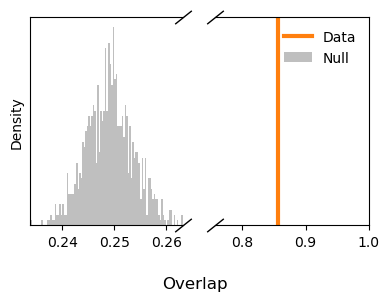

In [26]:
counts,bins = np.histogram(random_overlaps,density=True,
                          bins=100)
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

fig,ax = plt.subplots(1,2,sharey=True,figsize=(4,3))
### Plot same data in both axes
ax[0].bar(bin_centers,
       counts,
       width=dbin,
      alpha=0.5,label='Null',
       color='gray'
       # edgecolor='k'
      )
ax[0].axvline(overlap,#np.max(counts)/2,
           c='tab:orange',
           linewidth=3,
           #edgecolor='k',s=50,
           label='Data')
ax[1].bar(bin_centers,
       counts,
       width=dbin,
      alpha=0.5,label='Null',
       color='gray'
       # edgecolor='k'
      )
ax[1].axvline(overlap,#np.max(counts)/2,
           c='tab:orange',
           linewidth=3,
           #edgecolor='k',s=50,
           label='Data')
ax[0].set_xlim(bins[0]-dbin/2,bins[-1]+dbin/2)
ax[1].set_xlim(overlap-0.1,1)
ax[0].spines.right.set_visible(False)
ax[1].spines.left.set_visible(False)
ax[1].set_yticks([])
ax[1].tick_params(labelleft=False)

d = .8# proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax[0].plot([1, 1], [0, 1], transform=ax[0].transAxes, **kwargs)
ax[1].plot([0,0], [0, 1], transform=ax[1].transAxes, **kwargs)

fig.supxlabel('Overlap')
ax[0].set_ylabel('Density')
ax[1].legend(loc='best',frameon=False)
plt.tight_layout()
plt.savefig('{}.overlaps.png'.format(dataset_name),format='png',dpi=300)


ks_res = sp.stats.kstest([overlap],random_overlaps,
                        alternative='two-sided'
                        )

print(ks_res)
